# Exploratory Data Analysis

This notebook explores the cleaned MGMT methylation and gene expression dataset before applying linear regression.

The goal is to inspect the data, check for missing values, summarize the variables, and visualize the relationship between cg12981137 methylation and MGMT RNA expression.

In [ ]:
#IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
#LOAD DATASET
data_file = "../data/processed_data/mgmt_cg12981137_lr_data.tsv"
df = pd.read_csv(data_file, sep="\t")

In [5]:
#VIEW FIRST FEW ROWS
df.head()

,sample,cg12981137_methylation,MGMT_expression
0,TCGA-06-5418-01,0.0322,7.567
1,TCGA-19-1389-02,0.0154,7.575
2,TCGA-19-4065-02,0.0138,8.189
3,TCGA-32-1980-01,0.0183,8.074
4,TCGA-14-0736-02,0.0127,9.064


The dataset contains one row per TCGA sample. The input variable is cg12981137 methylation, and the target variable is MGMT expression.

In [8]:
#CHECK SHAPE 
df.shape

(65, 3)

In [9]:
#CHECK COLUMN NAMES
df.columns

Index(['sample', 'cg12981137_methylation', 'MGMT_expression'], dtype='str')

In [10]:
#CHECK FOR MISSING VALUES
df.isnull().sum()

sample                    0
cg12981137_methylation    0
MGMT_expression           0
dtype: int64

The cleaned dataset does not contain missing values in the methylation or expression columns, so no further missing-value handling is required at this stage.

In [11]:
#SUMMARY STATISTICS
df.describe()

,cg12981137_methylation,MGMT_expression
count,65.000000,65.000000
mean,0.208660,7.123369
std,0.264106,1.075480
min,0.012000,4.082000
25%,0.014900,6.327000
50%,0.025000,7.447000
75%,0.454400,7.906000
max,0.778800,9.064000


The cg12981137 methylation values are beta values, so they are expected to range from 0 to 1. MGMT expression values are continuous numerical values, making the dataset suitable for a simple regression task.

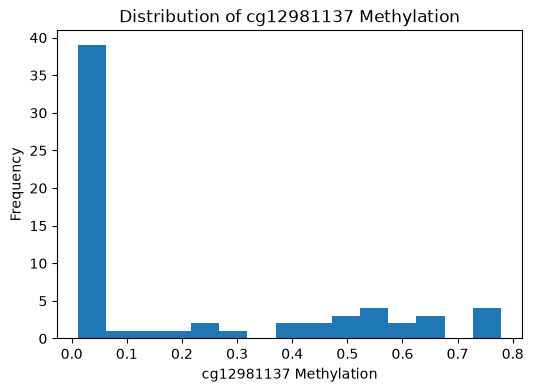

In [12]:
#METHYLATION HISTOGRAM
plt.figure(figsize=(6, 4))
plt.hist(df["cg12981137_methylation"], bins=15)
plt.xlabel("cg12981137 Methylation")
plt.ylabel("Frequency")
plt.title("Distribution of cg12981137 Methylation")
plt.show()

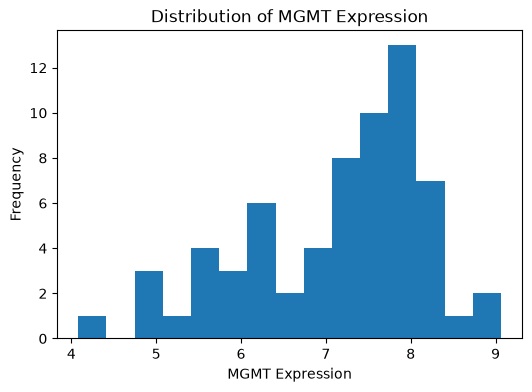

In [13]:
#MGMT EXPRESSION HISTOGRAM
plt.figure(figsize=(6, 4))
plt.hist(df["MGMT_expression"], bins=15)
plt.xlabel("MGMT Expression")
plt.ylabel("Frequency")
plt.title("Distribution of MGMT Expression")
plt.show()

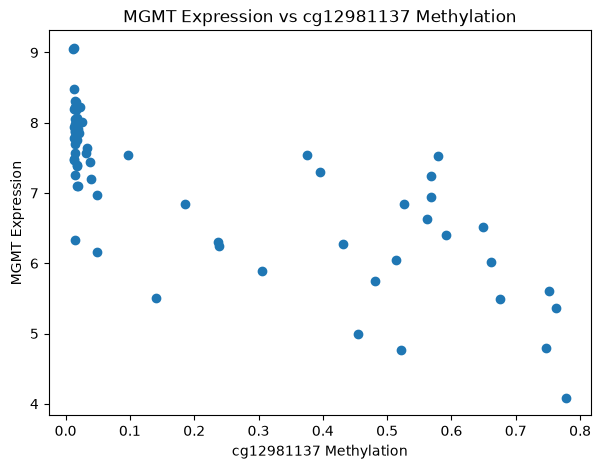

In [14]:
#SCATTERPLOT
plt.figure(figsize=(7, 5))
plt.scatter(
    df["cg12981137_methylation"],
    df["MGMT_expression"]
)

plt.xlabel("cg12981137 Methylation")
plt.ylabel("MGMT Expression")
plt.title("MGMT Expression vs cg12981137 Methylation")
plt.show()

The scatter plot shows a generally negative relationship between cg12981137 methylation and MGMT expression. Samples with higher methylation tend to have lower MGMT expression. This supports the biological expectation that promoter-associated methylation may be linked with reduced transcription.

In [15]:
#CORRELATION CALCULATION
correlation = df["cg12981137_methylation"].corr(
    df["MGMT_expression"]
)

correlation

np.float64(-0.7523622994270331)

The Pearson correlation between cg12981137 methylation and MGMT expression is approximately -0.75, indicating a strong negative linear relationship. This suggests that simple linear regression is a reasonable model to use for demonstrating the mathematical relationship between the two variables.

## EDA Conclusion

The dataset contains 65 TCGA samples with numerical values for cg12981137 methylation and MGMT expression. No missing values were found in the cleaned dataset. The scatter plot and Pearson correlation show a clear negative relationship between methylation and expression. Therefore, the dataset is appropriate for demonstrating simple linear regression from scratch.